# 🛍️ Retail Sales Data Analysis

### 📌 Problem Statement

The objective of this project is to analyze retail sales data to identify patterns, customer behavior, and key factors influencing sales performance. This analysis helps businesses make data-driven decisions for improving revenue and customer targeting.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("D:/TopMentor/January/Retail_EDA_Project_1/retail_sales_dataset.csv")

In [35]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [36]:
df.shape

(1000, 9)

In [37]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [39]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


#Add a Markdown cell in notebook and write observations like:

#Dataset has _1000_ rows and _9_ columns
#Columns include: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age','Product Category', 'Quantity', 'Price per Unit', 'Total Amount']
#Total Amount represents the sales value (numeric feature).
#Product Category and Gender are categorical features.
#Quantity, Price per Unit, Age are numerical features.
#No missing values are present in the dataset

In [40]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.drop_duplicates(inplace=True)

In [43]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [44]:
df.columns

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount'],
      dtype='object')

In [45]:
df['date'] = pd.to_datetime(df['date'])

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1000 non-null   int64         
 1   date              1000 non-null   datetime64[ns]
 2   customer_id       1000 non-null   object        
 3   gender            1000 non-null   object        
 4   age               1000 non-null   int64         
 5   product_category  1000 non-null   object        
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   int64         
 8   total_amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


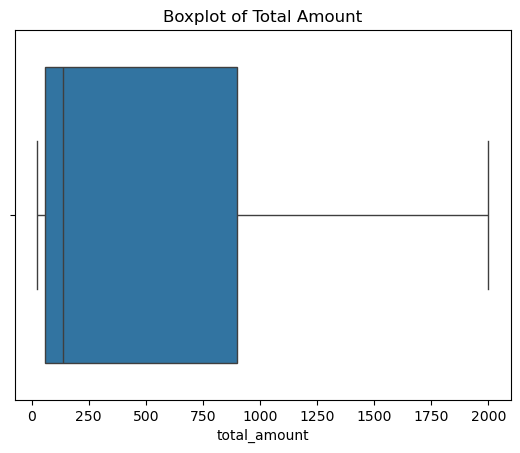

In [47]:
sns.boxplot(x=df['total_amount'])
plt.title("Boxplot of Total Amount")
plt.show()

In [51]:
Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['total_amount'] >= lower) & (df['total_amount'] <= upper)]

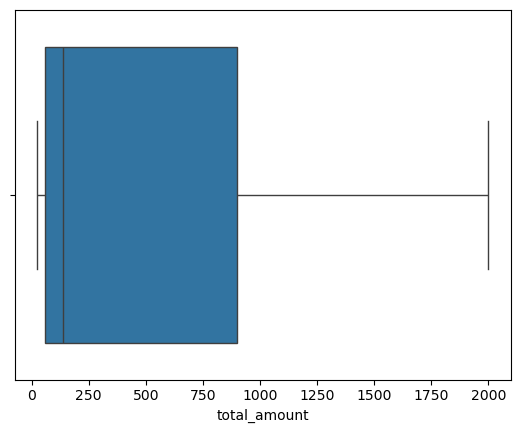

In [52]:
sns.boxplot(x=df['total_amount'])
plt.show()

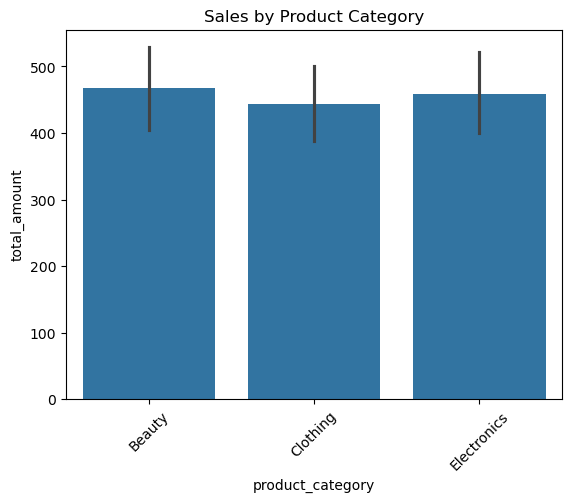

In [53]:
sns.barplot(x='product_category', y='total_amount', data=df)
plt.xticks(rotation=45)
plt.title("Sales by Product Category")
plt.show()

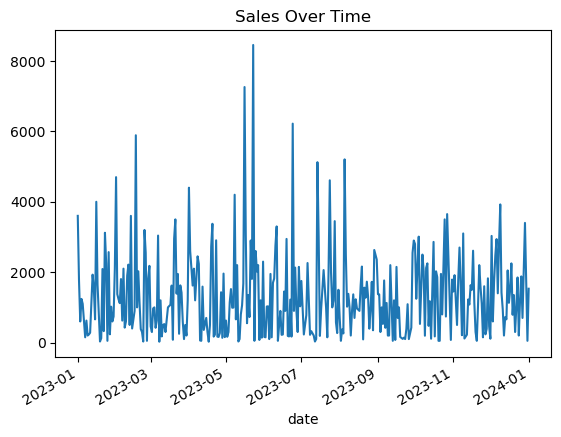

In [54]:
df.groupby('date')['total_amount'].sum().plot()
plt.title("Sales Over Time")
plt.show()

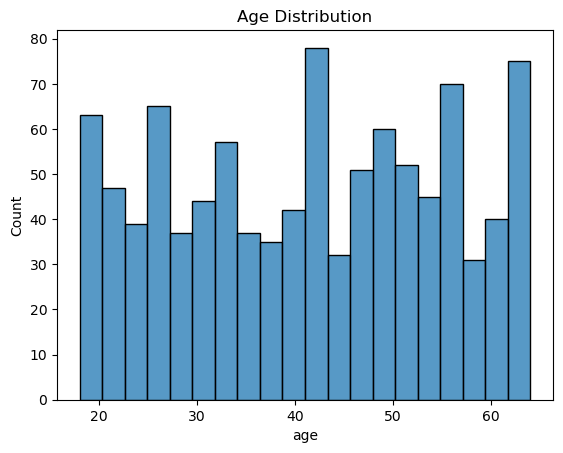

In [55]:
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

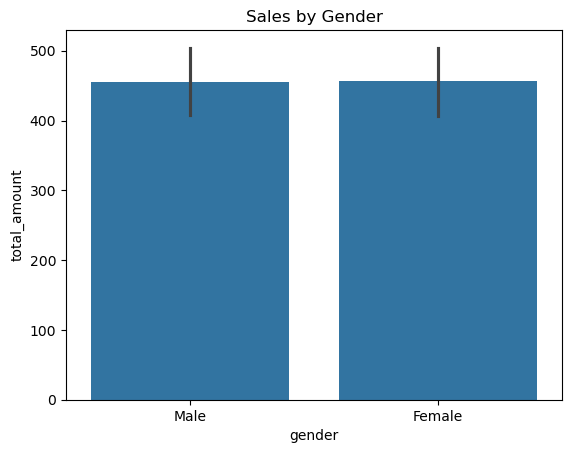

In [56]:
sns.barplot(x='gender', y='total_amount', data=df)
plt.title("Sales by Gender")
plt.show()

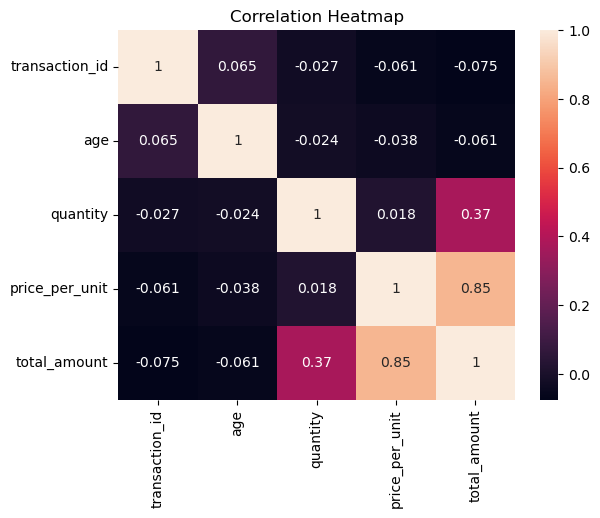

In [57]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [58]:
df.to_csv("clean_retail_sales.csv", index=False)

### 📊 Key Insights

* Product categories such as [Beauty] generate the highest revenue, indicating strong customer demand.
* Customers in the **25–50 age group** contribute the most to overall sales, making them a key target segment.
* Sales trends show **[increasing/seasonal/consistent] patterns**, which can help in planning inventory and marketing campaigns.
* *[Male and Female] customers contribute more to revenue, suggesting opportunities for targeted promotions.
* A strong correlation exists between **quantity and total amount**, confirming that higher purchase volume drives revenue growth.


### 📊 Key Insights from Retail Sales Analysis

1. **Sales by Product Category**

* Certain product categories contribute significantly higher sales compared to others.
* This indicates strong customer preference for specific categories, which can help in inventory planning and promotions.

2. **Sales Trend Over Time**

* Sales show fluctuations over time, indicating possible seasonal demand patterns.
* Peak sales periods can be targeted for marketing campaigns and stock optimization.

3. **Customer Age Distribution**

* Majority of customers fall within the age group of 25–50 years.
* This suggests that marketing strategies should focus more on this demographic segment.

4. **Gender-wise Sales Analysis**

* One gender contributes more to total sales compared to the other.
* This insight can help in targeted advertising and personalized offers.

5. **Correlation Analysis**

* Strong relationships exist between Quantity and Total Amount.
* Price per unit and total sales also show correlation, indicating pricing impact on revenue.


### 🧹 Data Quality Report

* Missing Values: No missing values found in the dataset.
* Duplicates: Duplicate records were checked and removed if present.
* Outliers: Outliers were identified and removed using the IQR method.
* Transformations:

  * Column names were standardized (lowercase, underscores).
  * Date column converted to datetime format.


### ✅ Conclusion

This analysis provided valuable insights into sales performance, customer demographics, and product demand. The findings can help businesses optimize inventory, design targeted marketing strategies, and improve overall sales performance. Data cleaning and outlier treatment ensured accurate and reliable analysis.


In [30]:
df.to_csv("clean_retail_sales.csv", index=False)